Feature: alcohol
Mean: 10.442111402741325
Median: 10.2
Mode: 9.5

Variance: 1.1711473380358497
Standard Deviation: 1.0821956098764445
Minimum: 8.4
Maximum: 14.9
Range: 6.5

Skewness: 0.8633132317223615
Kurtosis: 0.22117896845525786


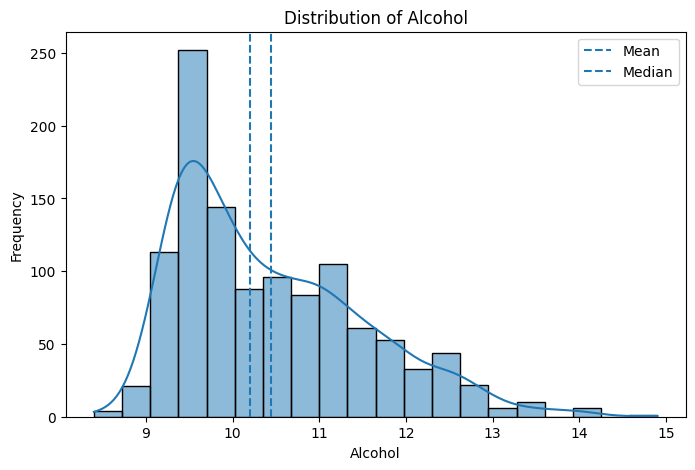


Mean vs Median
Mean is greater than median, suggesting right skewness.


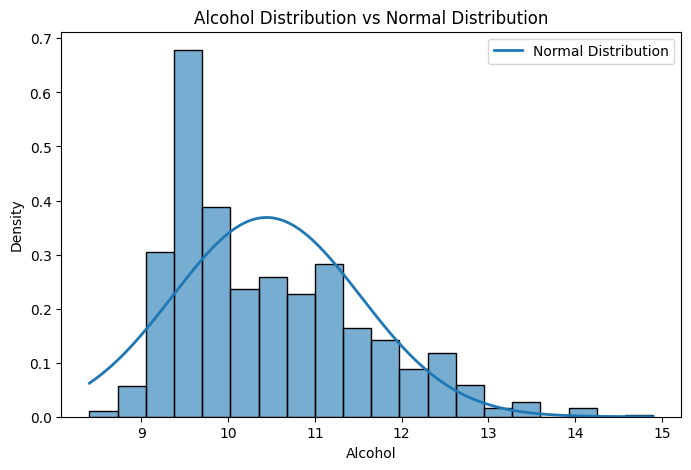


Empirical Rule
Within 1 standard deviation: 71.48 %
Within 2 standard deviations: 96.06 %
Within 3 standard deviations: 99.39 %

Z-Score Summary:
count    1.143000e+03
mean    -1.193563e-15
std      1.000438e+00
min     -1.887834e+00
25%     -8.709366e-01
50%     -2.238203e-01
75%      6.081863e-01
max      4.121103e+00
Name: alcohol_zscore, dtype: float64

Potential extreme values (|z| > 3):
     alcohol  alcohol_zscore
96      14.0        3.289097
98      14.0        3.289097
329     14.0        3.289097
419     14.0        3.289097
462     14.9        4.121103
589     14.0        3.289097
898     14.0        3.289097

Distribution Summary:


,Mean,Median,Std,Skewness
fixed acidity,8.311,7.900,1.748,1.045
volatile acidity,0.531,0.520,0.180,0.682
citric acid,0.268,0.250,0.197,0.372
density,0.997,0.997,0.002,0.102
pH,3.311,3.310,0.157,0.221
sulphates,0.658,0.620,0.170,2.497
alcohol,10.442,10.200,1.082,0.863


In [1]:
# ============================================================
# 03 - Distribution Analysis
# Wine Quality Dataset
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv("../data/WineQT.csv")

# ============================================================
# 1. Central Tendency
# ============================================================

feature = "alcohol"

print("Feature:", feature)
print("Mean:", df[feature].mean())
print("Median:", df[feature].median())
print("Mode:", df[feature].mode().iloc[0])

# ============================================================
# 2. Measures of Spread
# ============================================================

print("\nVariance:", df[feature].var())
print("Standard Deviation:", df[feature].std())
print("Minimum:", df[feature].min())
print("Maximum:", df[feature].max())
print("Range:", df[feature].max() - df[feature].min())

# ============================================================
# 3. Distribution Statistics
# ============================================================

print("\nSkewness:", df[feature].skew())
print("Kurtosis:", df[feature].kurt())

# ============================================================
# 4. Histogram
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x=feature,
    bins=20,
    kde=True
)

plt.axvline(
    df[feature].mean(),
    linestyle="--",
    label="Mean"
)

plt.axvline(
    df[feature].median(),
    linestyle="--",
    label="Median"
)

plt.title("Distribution of Alcohol")
plt.xlabel("Alcohol")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# ============================================================
# 5. Compare Mean and Median
# ============================================================

print("\nMean vs Median")

if abs(df[feature].mean() - df[feature].median()) < 0.1:
    print("Mean and median are close, suggesting a relatively symmetric distribution.")
elif df[feature].mean() > df[feature].median():
    print("Mean is greater than median, suggesting right skewness.")
else:
    print("Mean is less than median, suggesting left skewness.")

# ============================================================
# 6. Normal Distribution
# ============================================================

mean = df[feature].mean()
std = df[feature].std()

x = np.linspace(
    df[feature].min(),
    df[feature].max(),
    200
)

normal_curve = stats.norm.pdf(
    x,
    mean,
    std
)

plt.figure(figsize=(8, 5))

sns.histplot(
    df[feature],
    bins=20,
    stat="density",
    alpha=0.6
)

plt.plot(
    x,
    normal_curve,
    linewidth=2,
    label="Normal Distribution"
)

plt.title("Alcohol Distribution vs Normal Distribution")
plt.xlabel("Alcohol")
plt.ylabel("Density")
plt.legend()
plt.show()

# ============================================================
# 7. Empirical Rule
# ============================================================

within_1_std = df[
    (df[feature] >= mean - std) &
    (df[feature] <= mean + std)
]

within_2_std = df[
    (df[feature] >= mean - 2 * std) &
    (df[feature] <= mean + 2 * std)
]

within_3_std = df[
    (df[feature] >= mean - 3 * std) &
    (df[feature] <= mean + 3 * std)
]

print("\nEmpirical Rule")
print(
    "Within 1 standard deviation:",
    round(len(within_1_std) / len(df) * 100, 2),
    "%"
)

print(
    "Within 2 standard deviations:",
    round(len(within_2_std) / len(df) * 100, 2),
    "%"
)

print(
    "Within 3 standard deviations:",
    round(len(within_3_std) / len(df) * 100, 2),
    "%"
)

# ============================================================
# 8. Z-Scores
# ============================================================

df["alcohol_zscore"] = stats.zscore(df[feature])

print("\nZ-Score Summary:")
print(df["alcohol_zscore"].describe())

print("\nPotential extreme values (|z| > 3):")

extreme = df[
    abs(df["alcohol_zscore"]) > 3
]

print(extreme[[feature, "alcohol_zscore"]])

# ============================================================
# 9. Compare Multiple Features
# ============================================================

features = [
    "fixed acidity",
    "volatile acidity",
    "citric acid",
    "density",
    "pH",
    "sulphates",
    "alcohol"
]

distribution_summary = pd.DataFrame({
    "Mean": df[features].mean(),
    "Median": df[features].median(),
    "Std": df[features].std(),
    "Skewness": df[features].skew()
})

print("\nDistribution Summary:")
display(distribution_summary.round(3))